<a href="https://colab.research.google.com/github/saidnico3102-ops/Proyecto-FUVOL/blob/main/PROYECTO_FUVOL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Importación de Librerías

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_theme(style="whitegrid")


## 2. Carga y Construcción del Dataset (Data Governance)

Se integran `players.csv` y `appearances.csv` mediante la llave `player_id`.
Además de las variables numéricas, se incorporan dos variables categóricas
clave para el RF1 (Requerimiento Funcional 1): **posición en el campo** y
**liga de procedencia**, que más adelante se codificarán con One-Hot Encoding.



In [ ]:
print("Cargando bases de datos relacionales...")
players = pd.read_csv('players.csv')
appearances = pd.read_csv('appearances.csv')

# Agrupamos las estadísticas de aparición por jugador (suma histórica)
stats_jugador = appearances.groupby('player_id').agg({
    'minutes_played': 'sum',
    'goals': 'sum',
    'assists': 'sum',
    'yellow_cards': 'sum'
}).reset_index()

# Integración mediante llave primaria player_id (INNER JOIN)
df_completo = pd.merge(players, stats_jugador, on='player_id', how='inner')

columnas_utiles = ['name', 'date_of_birth', 'minutes_played', 'goals', 'assists',
                    'yellow_cards', 'market_value_in_eur']

# --- Variables categóricas (RF1): posición en el campo y liga de procedencia ---
# Nombres de columna estándar del dataset de Cariboo (2024). Si tu CSV usa
# nombres distintos, ajusta COL_POSICION / COL_LIGA aquí.
COL_POSICION = 'position' if 'position' in df_completo.columns else None
COL_LIGA = ('current_club_domestic_competition_id'
            if 'current_club_domestic_competition_id' in df_completo.columns else None)

if COL_POSICION:
    columnas_utiles.append(COL_POSICION)
if COL_LIGA:
    columnas_utiles.append(COL_LIGA)
if 'last_season' in df_completo.columns:
    columnas_utiles.append('last_season')

df = df_completo[columnas_utiles].copy()

# --- Cálculo de la edad respecto al año de extracción del dataset ---
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')
ANIO_REFERENCIA = 2026
df['Edad'] = ANIO_REFERENCIA - df['date_of_birth'].dt.year

# Limpieza: descartar nulos y jugadores sin cotización vigente
df = df.dropna(subset=['market_value_in_eur', 'Edad'])
df = df[df['market_value_in_eur'] > 0]

# --- Filtro de consistencia temporal (corrección del bug Edad-vs-Valor) ---
if 'last_season' in df.columns:
    df = df[df['last_season'] >= ANIO_REFERENCIA - 1]
    df = df.drop(columns=['last_season'])
else:
    df = df[df['Edad'] <= 40]  # tope razonable de carrera activa

df['Valor_Mercado'] = df['market_value_in_eur'] / 1_000_000  # a Millones de €

rename_map = {
    'name': 'Jugador',
    'minutes_played': 'Minutos_Jugados',
    'goals': 'Goles',
    'assists': 'Asistencias',
    'yellow_cards': 'Tarjetas_Amarillas'
}
if COL_POSICION:
    rename_map[COL_POSICION] = 'Posicion'
if COL_LIGA:
    rename_map[COL_LIGA] = 'Liga'

df = df.rename(columns=rename_map)
df = df.drop(columns=['date_of_birth', 'market_value_in_eur'])

# Rellenar categorías faltantes en vez de descartar registros completos
if 'Posicion' in df.columns:
    df['Posicion'] = df['Posicion'].fillna('Desconocido')
if 'Liga' in df.columns:
    df['Liga'] = df['Liga'].fillna('Desconocido')

print(f"¡Dataset Real Consolidado! Se procesaron {df.shape[0]} jugadores.")
display(df.head())


Cargando bases de datos relacionales...
¡Dataset Real Consolidado! Se procesaron 7327 jugadores.


,Jugador,Minutos_Jugados,Goles,Asistencias,Tarjetas_Amarillas,Posicion,Liga,Edad,Valor_Mercado
175,James Milner,26767,39,70,71,Midfield,GB1,40.0,0.75
396,Anastasios Tsokanis,21057,7,6,49,Midfield,GR1,35.0,0.20
616,Jonas Hofmann,22148,70,83,19,Midfield,L1,34.0,2.00
730,Cristiano Ronaldo,41150,432,114,64,Attack,SA1,41.0,15.00
863,Luiz Gustavo,28865,29,13,99,Midfield,BRA1,39.0,0.50


### 2.1 Definición de Grupos de Variables

In [ ]:
FEATURES_NUM = ["Edad", "Minutos_Jugados", "Goles", "Asistencias", "Tarjetas_Amarillas"]
CAT_COLS = [c for c in ["Posicion", "Liga"] if c in df.columns]
TARGET = "Valor_Mercado"

print("Variables numéricas:", FEATURES_NUM)
print("Variables categóricas detectadas:", CAT_COLS if CAT_COLS else
      "Ninguna (revisa los nombres de columna en tu players.csv)")
if CAT_COLS:
    for c in CAT_COLS:
        print(f"  - {c}: {df[c].nunique()} categorías únicas")


Variables numéricas: ['Edad', 'Minutos_Jugados', 'Goles', 'Asistencias', 'Tarjetas_Amarillas']
Variables categóricas detectadas: ['Posicion', 'Liga']
  - Posicion: 4 categorías únicas
  - Liga: 33 categorías únicas


## 3. Análisis Exploratorio de Datos (EDA)\n### 3.1 Estadísticas Descriptivas

In [ ]:
display(df.describe().round(2))


,Minutos_Jugados,Goles,Asistencias,Tarjetas_Amarillas,Edad,Valor_Mercado
count,7327.00,7327.00,7327.00,7327.00,7327.00,7327.00
mean,8101.38,12.48,9.72,15.98,27.83,5.69
std,8475.46,26.55,16.65,18.67,4.59,12.34
min,1.00,0.00,0.00,0.00,18.00,0.01
25%,1869.00,0.00,1.00,3.00,24.00,0.50
50%,5287.00,4.00,3.00,9.00,27.00,1.50
75%,11554.50,13.00,12.00,22.00,31.00,5.00
max,54203.00,528.00,224.00,142.00,44.00,200.00


### 3.2 Transformación Logarítmica de la Variable Objetivo

=== TRANSFORMACIÓN LOGARÍTMICA DE LA VARIABLE OBJETIVO ===


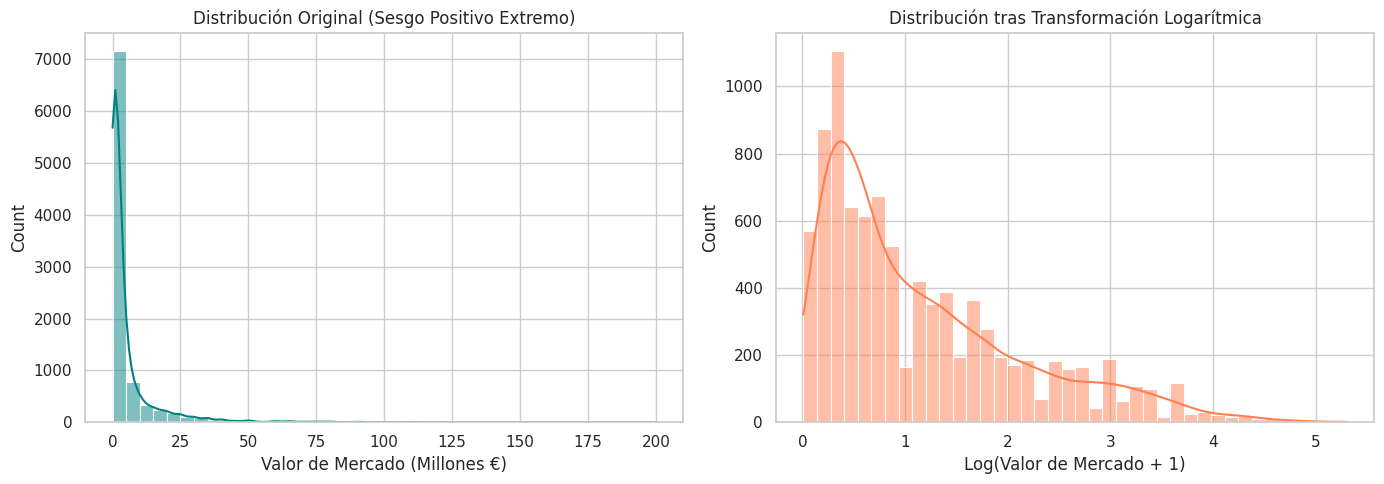

In [ ]:
print("=== TRANSFORMACIÓN LOGARÍTMICA DE LA VARIABLE OBJETIVO ===")

df_log = df.copy()
df_log['Valor_Mercado_Log'] = np.log1p(df_log['Valor_Mercado'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Valor_Mercado'], kde=True, ax=axes[0], color='teal', bins=40)
axes[0].set_title("Distribución Original (Sesgo Positivo Extremo)")
axes[0].set_xlabel("Valor de Mercado (Millones €)")

sns.histplot(df_log['Valor_Mercado_Log'], kde=True, ax=axes[1], color='coral', bins=40)
axes[1].set_title("Distribución tras Transformación Logarítmica")
axes[1].set_xlabel("Log(Valor de Mercado + 1)")

plt.tight_layout()
plt.show()


### 3.3 Matriz de Correlación de Pearson

=== MATRIZ DE CORRELACIÓN DE PEARSON ===


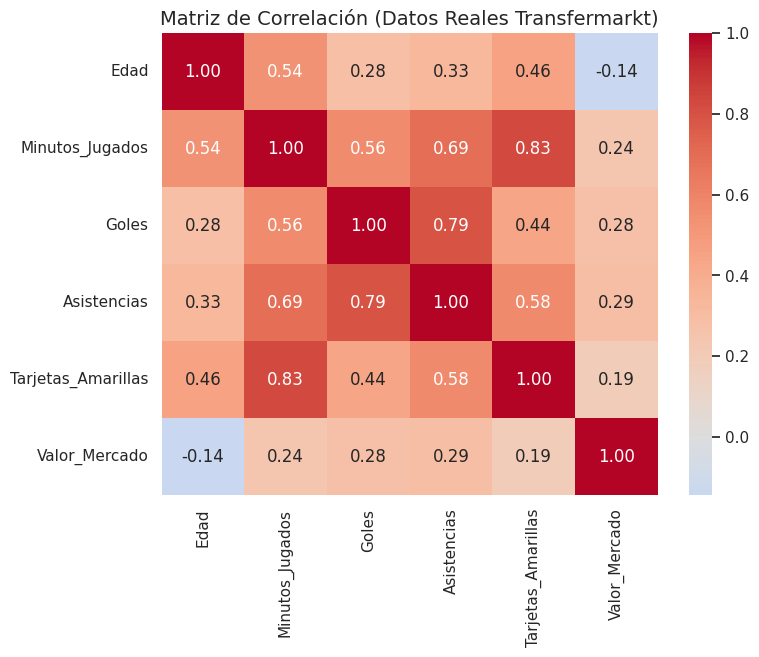

In [ ]:
print("=== MATRIZ DE CORRELACIÓN DE PEARSON ===")

columnas_numericas = FEATURES_NUM + [TARGET]
df_numerico = df[columnas_numericas]

plt.figure(figsize=(8, 6))
sns.heatmap(df_numerico.corr(), annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Matriz de Correlación (Datos Reales Transfermarkt)", fontsize=14)
plt.show()


=== DISTRIBUCIÓN DE ATRIBUTOS (ANTES DEL PREPROCESAMIENTO) ===


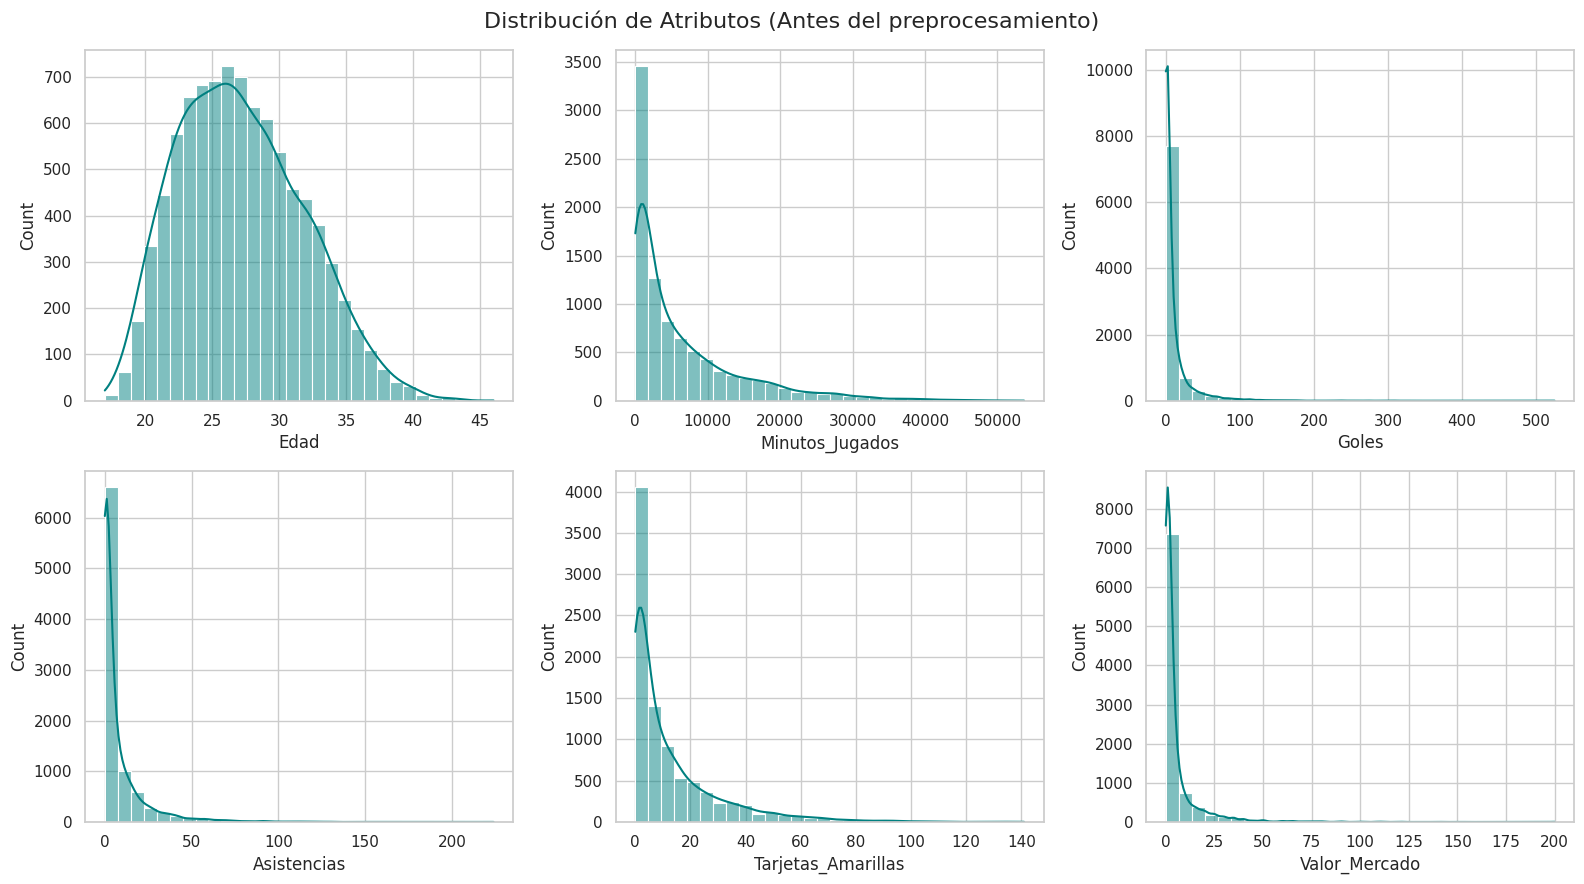

In [ ]:
print("=== DISTRIBUCIÓN DE ATRIBUTOS (ANTES DEL PREPROCESAMIENTO) ===")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribución de Atributos (Antes del preprocesamiento)', fontsize=16)
for i, col in enumerate(columnas_numericas):
    sns.histplot(df_numerico[col], kde=True, ax=axes[i // 3, i % 3], color='teal', bins=30)
plt.tight_layout()
plt.show()


### 3.4 Diagnóstico Formal de Multicolinealidad (VIF)

El Factor de Inflación de la Varianza (VIF) cuantifica numéricamente lo que
la matriz de correlación solo sugiere visualmente. Regla práctica:
**VIF > 5** indica multicolinealidad relevante; **VIF > 10**, severa.

In [ ]:
print("=== FACTOR DE INFLACIÓN DE LA VARIANZA (VIF) ===")

X_vif = sm.add_constant(df[FEATURES_NUM])
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

display(vif_data[vif_data["Variable"] != "const"].sort_values("VIF", ascending=False).round(2))

print("\nLas variables con VIF elevado son las que justifican aplicar PCA")
print("en la sección 6, en lugar de eliminarlas manualmente y perder información.")


=== FACTOR DE INFLACIÓN DE LA VARIANZA (VIF) ===


,Variable,VIF
2,Minutos_Jugados,4.48
4,Asistencias,3.52
5,Tarjetas_Amarillas,3.19
3,Goles,2.71
1,Edad,1.41



Las variables con VIF elevado son las que justifican aplicar PCA
en la sección 6, en lugar de eliminarlas manualmente y perder información.


### 3.5 Tratamiento Ilustrativo de Outliers (IQR)

> **Nota metodológica:** este recorte es solo demostrativo, para justificar
> visualmente por qué **no** se usó en el modelo final. Aplicar límites IQR
> eliminaría información real sobre los jugadores de élite (distribución de
> Pareto). Por eso se prefirió la transformación logarítmica (sección 3.2).

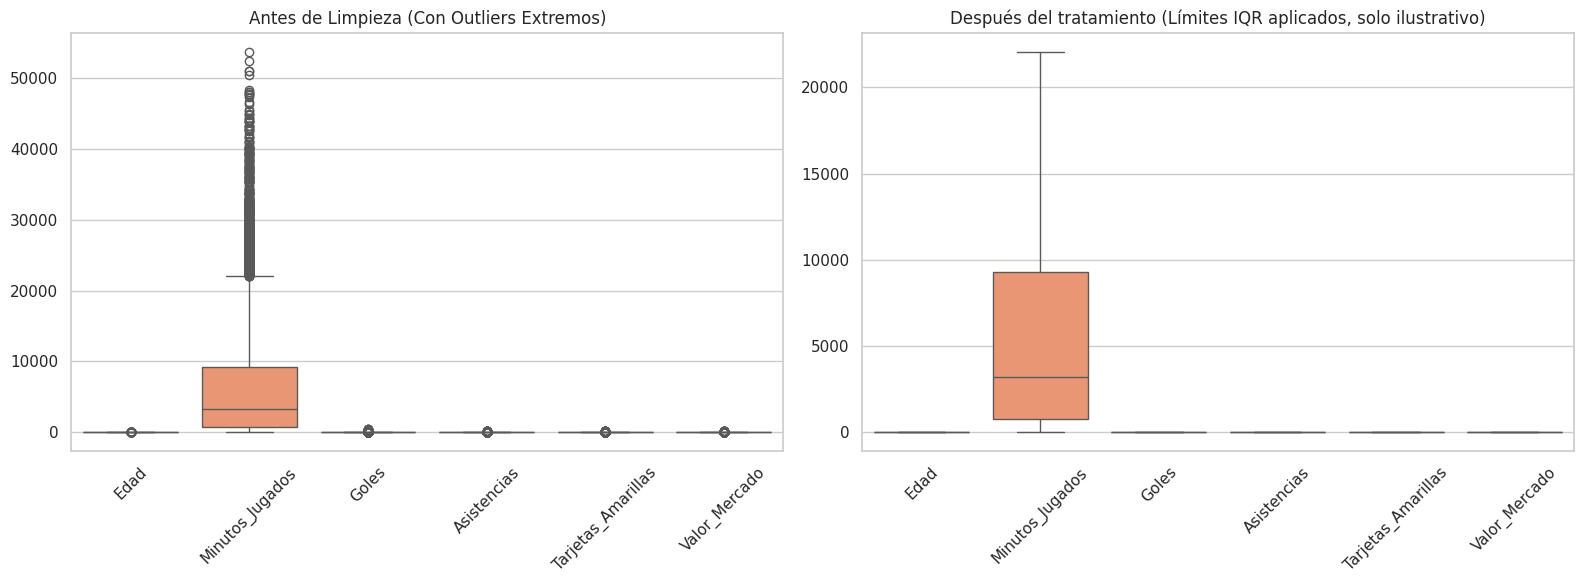

In [ ]:
df_out = df_numerico.copy()
for col in df_out.columns:
    Q1, Q3 = df_out[col].quantile(0.25), df_out[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_lim, upper_lim = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    df_out[col] = np.where(df_out[col] < lower_lim, lower_lim, df_out[col])
    df_out[col] = np.where(df_out[col] > upper_lim, upper_lim, df_out[col])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=df_numerico, ax=axes[0], palette="Set2")
axes[0].set_title("Antes de Limpieza (Con Outliers Extremos)")
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_out, ax=axes[1], palette="Set2")
axes[1].set_title("Después del tratamiento (Límites IQR aplicados, solo ilustrativo)")
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


### 3.6 Relación entre Predictores Clave y el Valor de Mercado

=== RELACIÓN ENTRE PREDICTORES CLAVE Y EL VALOR DE MERCADO ===


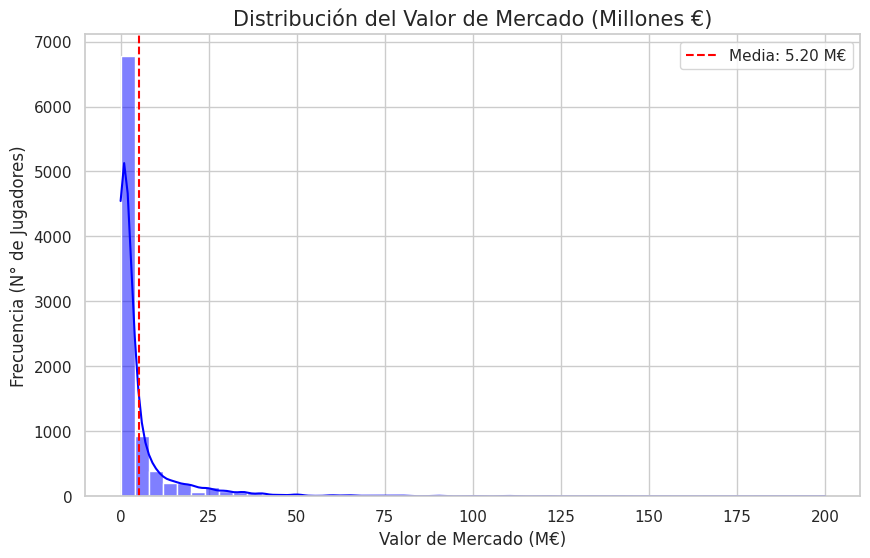

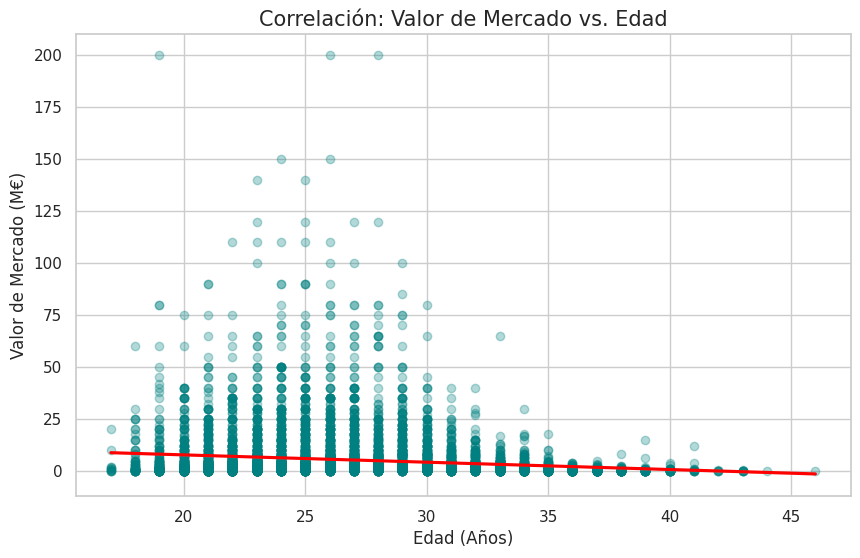

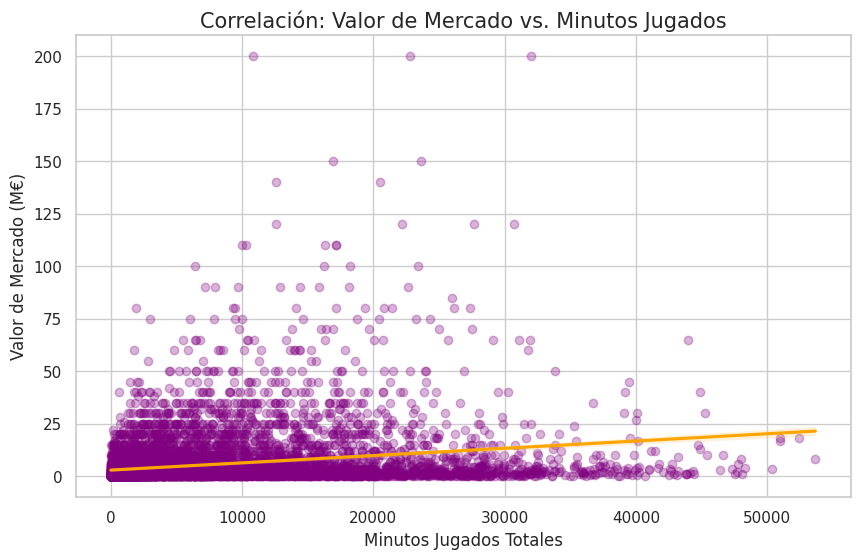

In [ ]:
print("=== RELACIÓN ENTRE PREDICTORES CLAVE Y EL VALOR DE MERCADO ===")

plt.figure(figsize=(10, 6))
sns.histplot(df['Valor_Mercado'], kde=True, color='blue', bins=50)
plt.title('Distribución del Valor de Mercado (Millones €)', fontsize=15)
plt.xlabel('Valor de Mercado (M€)')
plt.ylabel('Frecuencia (N° de Jugadores)')
plt.axvline(df['Valor_Mercado'].mean(), color='red', linestyle='--',
            label=f'Media: {df["Valor_Mercado"].mean():.2f} M€')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Edad', y='Valor_Mercado',
            scatter_kws={'alpha': 0.3, 'color': 'teal'}, line_kws={'color': 'red'})
plt.title('Correlación: Valor de Mercado vs. Edad', fontsize=15)
plt.xlabel('Edad (Años)')
plt.ylabel('Valor de Mercado (M€)')
plt.show()

plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Minutos_Jugados', y='Valor_Mercado',
            scatter_kws={'alpha': 0.3, 'color': 'purple'}, line_kws={'color': 'orange'})
plt.title('Correlación: Valor de Mercado vs. Minutos Jugados', fontsize=15)
plt.xlabel('Minutos Jugados Totales')
plt.ylabel('Valor de Mercado (M€)')
plt.show()


## 4. Codificación One-Hot de Variables Categóricas

Se codifican `Posicion` y `Liga` mediante One-Hot Encoding (`drop_first=True`
para evitar la trampa de la variable ficticia / colinealidad perfecta entre
dummies).

In [ ]:
print("=== CODIFICACIÓN ONE-HOT DE VARIABLES CATEGÓRICAS ===")

if CAT_COLS:
    df_encoded = pd.get_dummies(df, columns=CAT_COLS, drop_first=True)
    FEATURES_CAT = [c for c in df_encoded.columns if c not in df.columns]
else:
    df_encoded = df.copy()
    FEATURES_CAT = []

print(f"Se generaron {len(FEATURES_CAT)} variables dummy a partir de {CAT_COLS}.")
display(df_encoded.head())


=== CODIFICACIÓN ONE-HOT DE VARIABLES CATEGÓRICAS ===
Se generaron 35 variables dummy a partir de ['Posicion', 'Liga'].


,Jugador,Minutos_Jugados,Goles,Asistencias,Tarjetas_Amarillas,Edad,Valor_Mercado,Posicion_Defender,Posicion_Goalkeeper,Posicion_Midfield,...,Liga_RO1,Liga_RSK1,Liga_RU1,Liga_SA1,Liga_SC1,Liga_SE1,Liga_SER1,Liga_TR1,Liga_TS1,Liga_UKR1
175,James Milner,26708,39,70,71,40.0,0.75,False,False,True,...,False,False,False,False,False,False,False,False,False,False
396,Anastasios Tsokanis,21057,7,6,49,35.0,0.20,False,False,True,...,False,False,False,False,False,False,False,False,False,False
616,Jonas Hofmann,22111,70,83,19,34.0,2.00,False,False,True,...,False,False,False,False,False,False,False,False,False,False
730,Cristiano Ronaldo,41150,432,114,64,41.0,12.00,False,False,False,...,False,False,False,True,False,False,False,False,False,False
863,Luiz Gustavo,28865,29,13,99,39.0,0.20,False,False,True,...,False,False,False,False,False,False,False,False,False,False


## 5. Análisis de Importancia de Variables (RandomForestRegressor)

Se utiliza `RandomForestRegressor` —**no** `RandomForestClassifier`, ya que
`Valor_Mercado` es una variable continua— únicamente como herramienta
exploratoria de importancia de variables (reducción promedio de impureza),
**no** como modelo predictivo final. El modelo final sigue siendo la
Regresión Lineal Múltiple (sección 7), por su mayor interpretabilidad.

=== ANÁLISIS DE IMPORTANCIA DE VARIABLES (RandomForestRegressor) ===


/tmp/ipykernel_4530/1320029570.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias_rf.values, y=importancias_rf.index, palette="viridis")


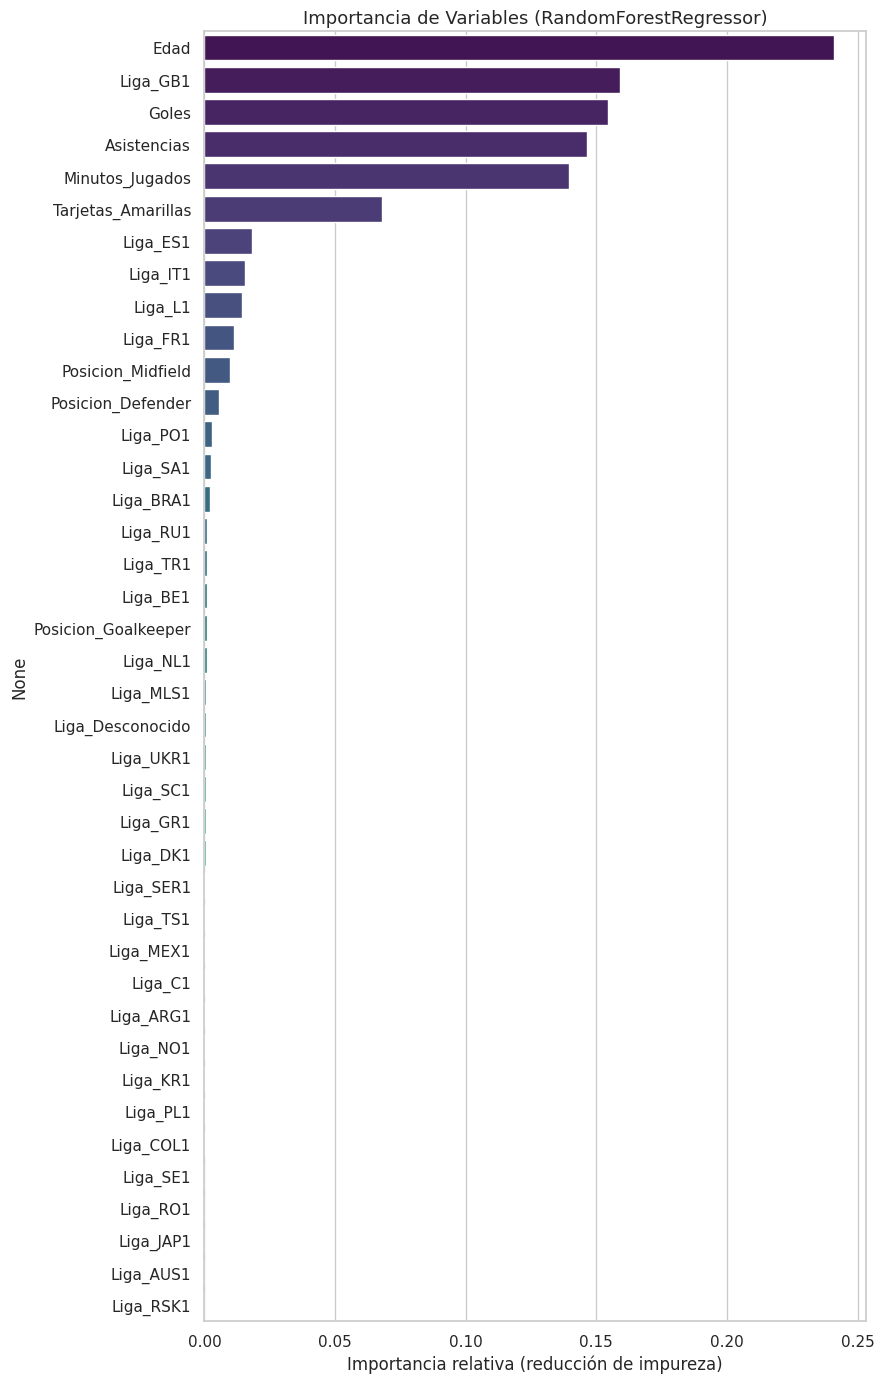

,0
Edad,0.2412
Liga_GB1,0.1590
Goles,0.1544
Asistencias,0.1465
Minutos_Jugados,0.1396
Tarjetas_Amarillas,0.0679
Liga_ES1,0.0181
Liga_IT1,0.0155
Liga_L1,0.0142
Liga_FR1,0.0112


In [ ]:
print("=== ANÁLISIS DE IMPORTANCIA DE VARIABLES (RandomForestRegressor) ===")

FEATURES_FULL = FEATURES_NUM + FEATURES_CAT

df_rf = df_encoded[FEATURES_FULL + [TARGET]].dropna()
X_rf = df_rf[FEATURES_FULL]
y_rf = df_rf[TARGET]

X_rf_train, X_rf_test, y_rf_train, y_rf_test = train_test_split(
    X_rf, y_rf, test_size=0.20, random_state=42
)

rf_modelo = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_modelo.fit(X_rf_train, y_rf_train)

importancias_rf = pd.Series(
    rf_modelo.feature_importances_, index=FEATURES_FULL
).sort_values(ascending=False)

plt.figure(figsize=(9, max(4, 0.35 * len(importancias_rf))))
sns.barplot(x=importancias_rf.values, y=importancias_rf.index, palette="viridis")
plt.title("Importancia de Variables (RandomForestRegressor)", fontsize=13)
plt.xlabel("Importancia relativa (reducción de impureza)")
plt.tight_layout()
plt.show()

display(importancias_rf.round(4))


## 6. Preprocesamiento: División, Estandarización y PCA

**Orden correcto (sin fuga de datos):** primero se divide en `train`/`test`,
y solo **después** se ajustan (`fit`) el `StandardScaler` y el `PCA`
exclusivamente con los datos de entrenamiento. El conjunto de prueba
únicamente se transforma (`transform`), nunca se usa para ajustar.

> **Nota de diseño:** se incluyen tanto las variables numéricas como las
> variables dummy (0/1) en el mismo `StandardScaler` + `PCA` para mantener
> un único pipeline consistente. Una alternativa más purista sería
> estandarizar solo las variables continuas y dejar las dummies sin escalar;
> dado el bajo número de categorías, el efecto práctico es mínimo.

In [ ]:
print("=== PREPROCESAMIENTO: DIVISIÓN, ESTANDARIZACIÓN Y PCA ===")

FEATURES = FEATURES_NUM + FEATURES_CAT

df_model = df_encoded[FEATURES + [TARGET]].dropna()
df_model["Valor_Mercado_Log"] = np.log1p(df_model[TARGET])

X = df_model[FEATURES].values
y = df_model["Valor_Mercado_Log"].values

# División 80/20 con semilla fija para reproducibilidad
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Estandarización: ajustada SOLO con train (evita fuga de información)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA: ajustado SOLO con train, reteniendo 95% de varianza
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Variables totales utilizadas ({len(FEATURES)}): {FEATURES}")
print(f"Total de registros para Entrenamiento (80%): {X_train.shape[0]}")
print(f"Total de registros para Pruebas (20%): {X_test.shape[0]}")
print(f"Componentes principales retenidos: {pca.n_components_} "
      f"(varianza explicada: {pca.explained_variance_ratio_.sum():.4f})")


=== PREPROCESAMIENTO: DIVISIÓN, ESTANDARIZACIÓN Y PCA ===
Variables totales utilizadas (40): ['Edad', 'Minutos_Jugados', 'Goles', 'Asistencias', 'Tarjetas_Amarillas', 'Posicion_Defender', 'Posicion_Goalkeeper', 'Posicion_Midfield', 'Liga_ARG1', 'Liga_AUS1', 'Liga_BE1', 'Liga_BRA1', 'Liga_C1', 'Liga_COL1', 'Liga_DK1', 'Liga_Desconocido', 'Liga_ES1', 'Liga_FR1', 'Liga_GB1', 'Liga_GR1', 'Liga_IT1', 'Liga_JAP1', 'Liga_KR1', 'Liga_L1', 'Liga_MEX1', 'Liga_MLS1', 'Liga_NL1', 'Liga_NO1', 'Liga_PL1', 'Liga_PO1', 'Liga_RO1', 'Liga_RSK1', 'Liga_RU1', 'Liga_SA1', 'Liga_SC1', 'Liga_SE1', 'Liga_SER1', 'Liga_TR1', 'Liga_TS1', 'Liga_UKR1']
Total de registros para Entrenamiento (80%): 7250
Total de registros para Pruebas (20%): 1813
Componentes principales retenidos: 34 (varianza explicada: 0.9560)


## 7. Entrenamiento del Modelo (Regresión Lineal Múltiple — OLS)

In [ ]:
print("=== ENTRENAMIENTO DEL MODELO DE REGRESIÓN LINEAL MÚLTIPLE (OLS) ===")

modelo_rlm = LinearRegression(fit_intercept=True)
modelo_rlm.fit(X_train_pca, y_train)

print("Modelo entrenado correctamente sobre el espacio de componentes principales.")


=== ENTRENAMIENTO DEL MODELO DE REGRESIÓN LINEAL MÚLTIPLE (OLS) ===
Modelo entrenado correctamente sobre el espacio de componentes principales.


## 8. Validación Cruzada (K-Fold, K = 5)

`kfold` se define **una sola vez, aquí**, antes de cualquier celda que lo
use (corrección del `NameError` que rompía la ejecución en orden lineal).

=== VALIDACIÓN CRUZADA (K-FOLD, K=5) ===
R² promedio en TRAIN (CV): 0.4822 +/- 0.0032
R² promedio en VALID (CV): 0.4771 +/- 0.0129
Diferencia (Train - Valid): 0.0051


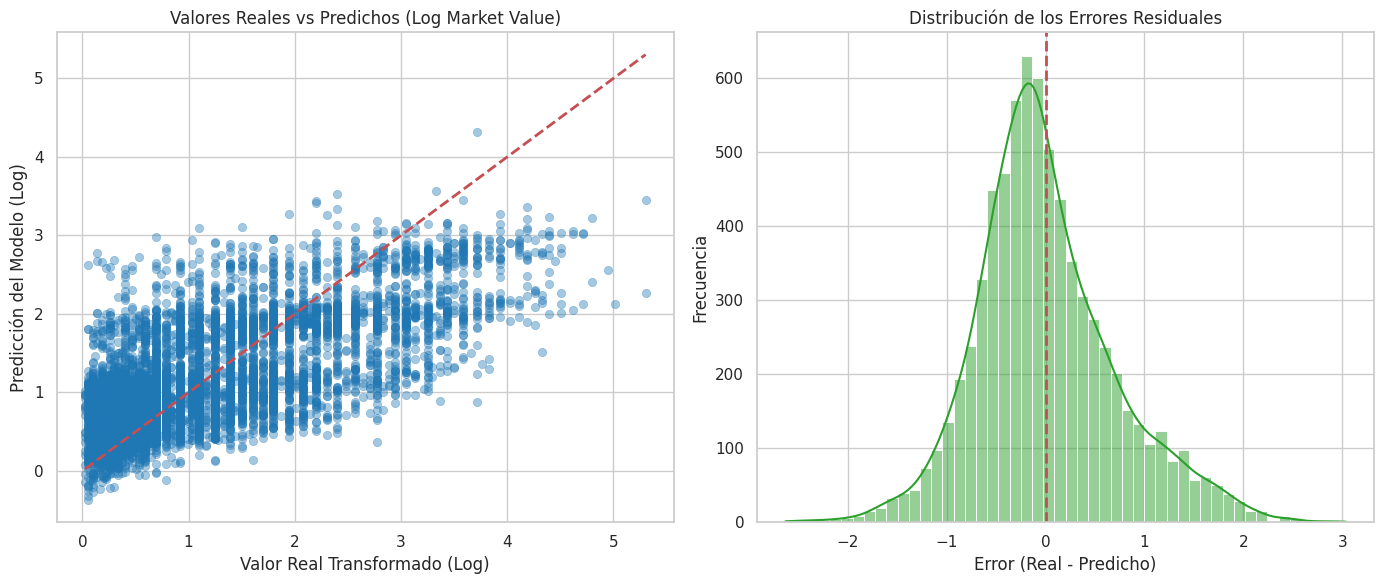


R² global (CV): 0.4774
MSE global (CV): 0.5007
RMSE global (CV): 0.7076


In [ ]:
print("=== VALIDACIÓN CRUZADA (K-FOLD, K=5) ===")

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    modelo_rlm, X_train_pca, y_train,
    cv=kfold, scoring={'r2': 'r2'}, return_train_score=True
)

train_r2_mean = cv_results["train_r2"].mean()
val_r2_mean = cv_results["test_r2"].mean()

print(f"R² promedio en TRAIN (CV): {train_r2_mean:.4f} +/- {cv_results['train_r2'].std():.4f}")
print(f"R² promedio en VALID (CV): {val_r2_mean:.4f} +/- {cv_results['test_r2'].std():.4f}")
print(f"Diferencia (Train - Valid): {abs(train_r2_mean - val_r2_mean):.4f}")

# Predicciones acumuladas para los gráficos de diagnóstico
y_pred_cv = cross_val_predict(modelo_rlm, X_train_pca, y_train, cv=kfold)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_train, y=y_pred_cv, alpha=0.4, color="#1f77b4", edgecolor=None)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.title("Valores Reales vs Predichos (Log Market Value)")
plt.xlabel("Valor Real Transformado (Log)")
plt.ylabel("Predicción del Modelo (Log)")

residuos = y_train - y_pred_cv
plt.subplot(1, 2, 2)
sns.histplot(residuos, kde=True, color="#2ca02c", bins=50)
plt.axvline(x=0, color='r', linestyle='--', lw=2)
plt.title("Distribución de los Errores Residuales")
plt.xlabel("Error (Real - Predicho)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

print(f"\nR² global (CV): {r2_score(y_train, y_pred_cv):.4f}")
print(f"MSE global (CV): {mean_squared_error(y_train, y_pred_cv):.4f}")
print(f"RMSE global (CV): {np.sqrt(mean_squared_error(y_train, y_pred_cv)):.4f}")


## 9. Evaluación Final en Test Set y Validación de Supuestos (Gauss-Markov)

=== EVALUACIÓN FINAL EN TEST SET Y VALIDACIÓN DE SUPUESTOS (GAUSS-MARKOV) ===

--- RENDIMIENTO EN DATOS NO VISTOS (TEST SET) ---
Coeficiente de Determinación (R²): 0.5079
Error Cuadrático Medio (MSE): 0.4931
Raíz del Error Cuadrático Medio (RMSE): 0.7022


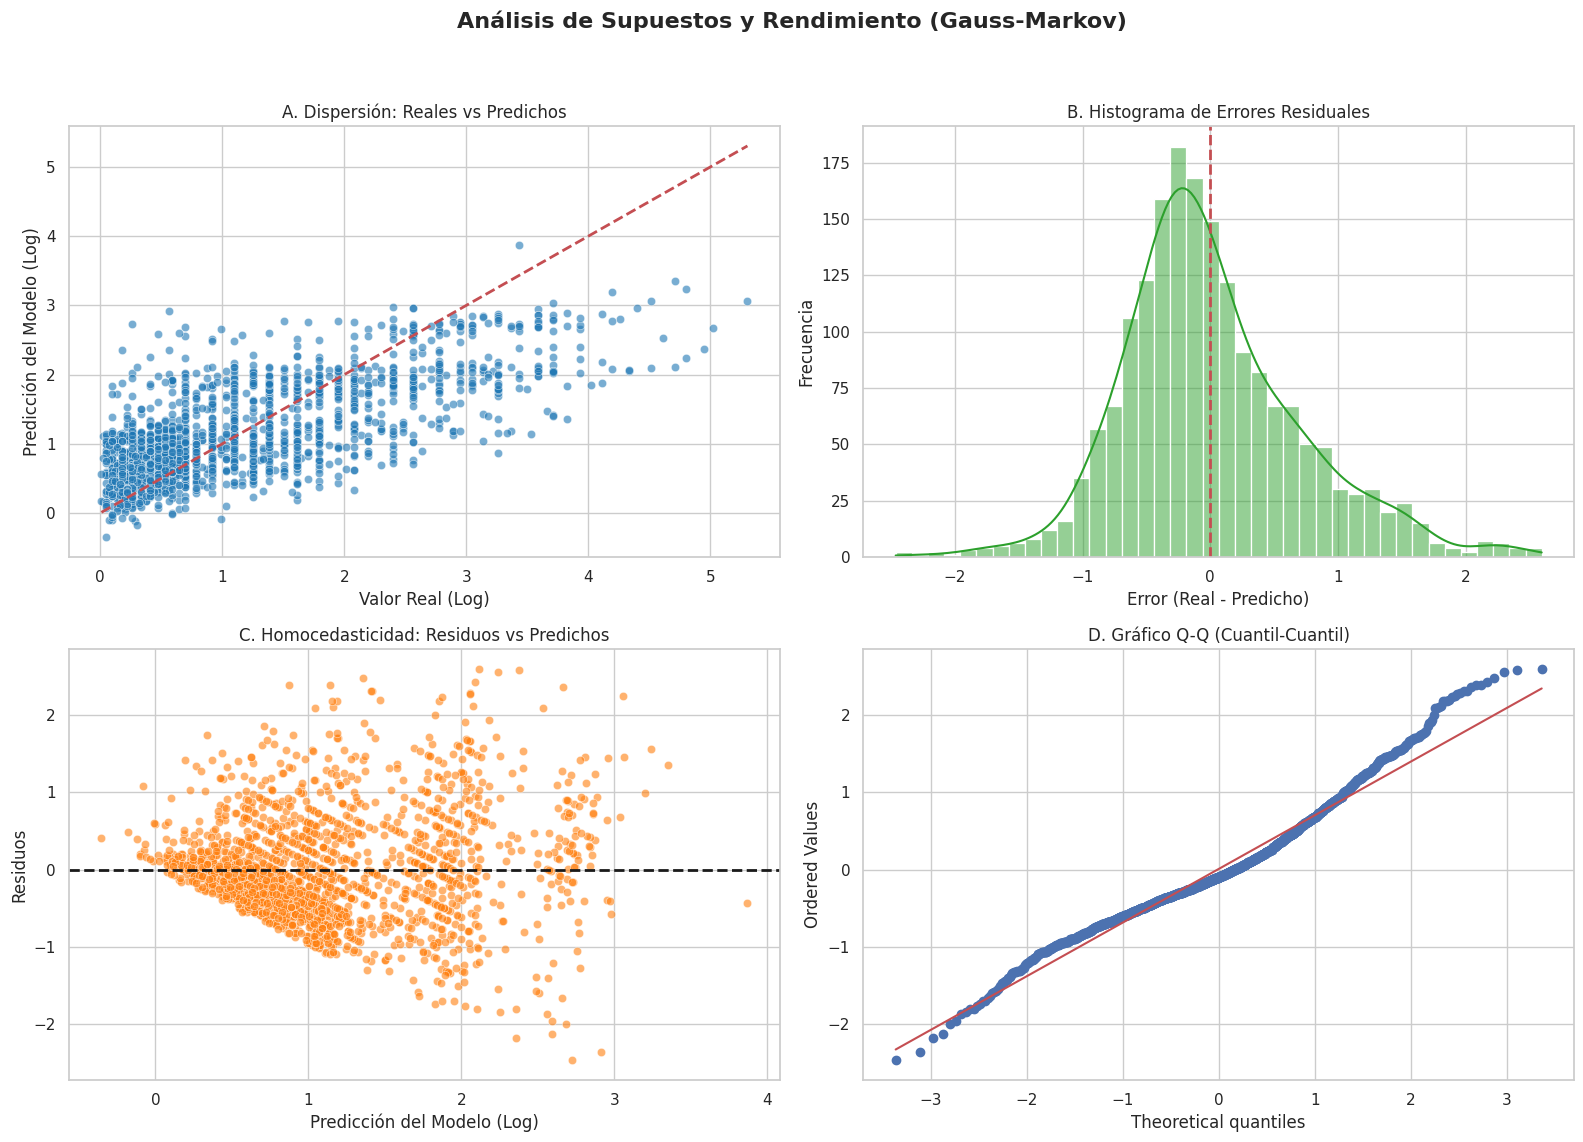


--- INTERPRETABILIDAD FINANCIERA ---
Error Absoluto Medio (MAE): El modelo se desvía en promedio por 3.91 Millones de Euros.


In [ ]:
print("=== EVALUACIÓN FINAL EN TEST SET Y VALIDACIÓN DE SUPUESTOS (GAUSS-MARKOV) ===")

y_pred_test = modelo_rlm.predict(X_test_pca)

r2_test = r2_score(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)

print("\n--- RENDIMIENTO EN DATOS NO VISTOS (TEST SET) ---")
print(f"Coeficiente de Determinación (R²): {r2_test:.4f}")
print(f"Error Cuadrático Medio (MSE): {mse_test:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_test:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Análisis de Supuestos y Rendimiento (Gauss-Markov)", fontsize=16, fontweight='bold')

# A. Reales vs Predichos
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.6, color="#1f77b4", ax=axes[0, 0])
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_title("A. Dispersión: Reales vs Predichos", fontsize=12)
axes[0, 0].set_xlabel("Valor Real (Log)")
axes[0, 0].set_ylabel("Predicción del Modelo (Log)")

# B. Histograma de residuos (normalidad)
residuos_test = y_test - y_pred_test
sns.histplot(residuos_test, kde=True, color="#2ca02c", bins=40, ax=axes[0, 1])
axes[0, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_title("B. Histograma de Errores Residuales", fontsize=12)
axes[0, 1].set_xlabel("Error (Real - Predicho)")
axes[0, 1].set_ylabel("Frecuencia")

# C. Homocedasticidad
sns.scatterplot(x=y_pred_test, y=residuos_test, alpha=0.6, color="#ff7f0e", ax=axes[1, 0])
axes[1, 0].axhline(y=0, color='k', linestyle='--', lw=2)
axes[1, 0].set_title("C. Homocedasticidad: Residuos vs Predichos", fontsize=12)
axes[1, 0].set_xlabel("Predicción del Modelo (Log)")
axes[1, 0].set_ylabel("Residuos")

# D. Q-Q Plot (normalidad estricta)
stats.probplot(residuos_test, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("D. Gráfico Q-Q (Cuantil-Cuantil)", fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Interpretabilidad de negocio: conversión a valor financiero real
y_test_dinero = np.expm1(y_test)
y_pred_test_dinero = np.expm1(y_pred_test)
mae_dinero = mean_absolute_error(y_test_dinero, y_pred_test_dinero)

print("\n--- INTERPRETABILIDAD FINANCIERA ---")
print(f"Error Absoluto Medio (MAE): El modelo se desvía en promedio por {mae_dinero:.2f} Millones de Euros.")


## 10. Interpretabilidad de Negocio: Coeficientes por Variable Original

Como `StandardScaler` y `PCA` son transformaciones **lineales**, sus efectos
son componibles algebraicamente. Esto permite traducir los coeficientes del
modelo (que viven en el espacio de componentes principales) de vuelta al
espacio original (`Edad`, `Goles`, `Posicion_*`, `Liga_*`, etc.), recuperando
así la interpretabilidad "caja blanca" que justifica el uso de Regresión
Lineal frente a modelos de caja negra (Random Forest, Redes Neuronales).

=== INTERPRETABILIDAD: IMPACTO POR VARIABLE ORIGINAL ===
Impacto aproximado de cada variable sobre Log(Valor_Mercado + 1):



,0
Liga_GB1,0.3403
Edad,-0.1825
Liga_IT1,0.1664
Liga_L1,0.1587
Liga_UKR1,-0.1290
Liga_FR1,0.1271
Liga_GR1,-0.1207
Liga_SC1,-0.1166
Liga_ES1,0.1138
Liga_PL1,-0.0814


/tmp/ipykernel_4530/1586481716.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancia.values, y=importancia.index, palette="coolwarm")


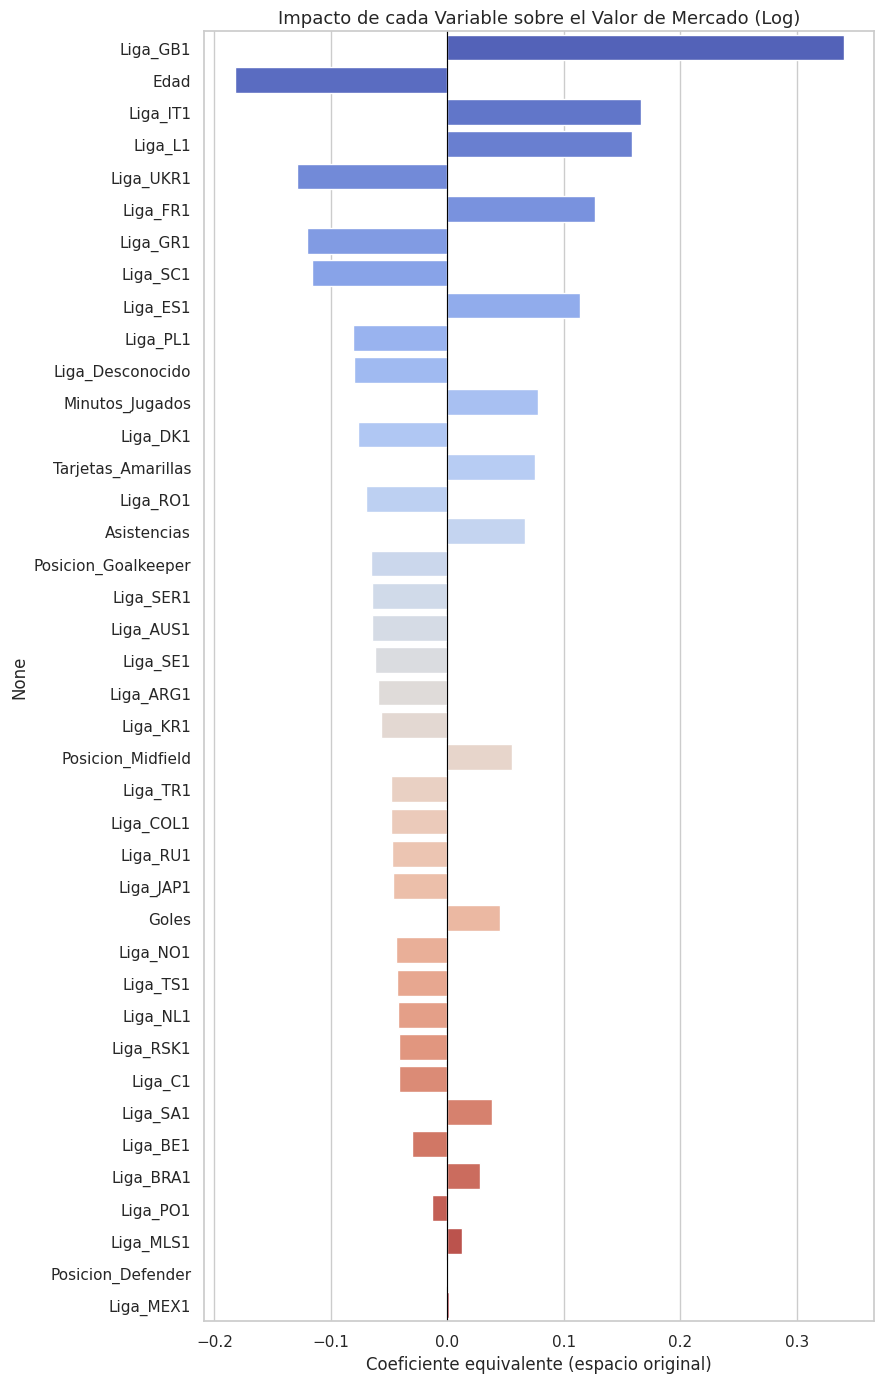

In [ ]:
print("=== INTERPRETABILIDAD: IMPACTO POR VARIABLE ORIGINAL ===")

coef_originales = modelo_rlm.coef_ @ pca.components_
importancia = pd.Series(coef_originales, index=FEATURES).sort_values(key=abs, ascending=False)

print("Impacto aproximado de cada variable sobre Log(Valor_Mercado + 1):\n")
display(importancia.round(4))

plt.figure(figsize=(9, max(4, 0.35 * len(importancia))))
sns.barplot(x=importancia.values, y=importancia.index, palette="coolwarm")
plt.title("Impacto de cada Variable sobre el Valor de Mercado (Log)", fontsize=13)
plt.xlabel("Coeficiente equivalente (espacio original)")
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()
